# Network Analysis

In [1]:
import math, copy, os, glob, random, sys, json, torch, numpy as np, matplotlib.pyplot as plt, pandas as pd
from torch.utils.data import DataLoader, sampler, Subset
from torch import tensor
sys.path.append("../../dataset/")
from dataset import EEGDataset2DLeftRight, ToTensor
from utility import train_validate_split_5_fold_CV, sample_single_class_indices
from datetime import datetime
sys.path.append("../../src/models/")
from snn import WrapCUBASpikingCNN as WrapSNN2C

def get_device(prefer_mps = True):
    """
    Choose a device, preferring Apple MPS if available, then CUDA, else CPU.

    :param prefer_mps: Whether to prefer Apple Metal (MPS) backend when available.
    :return: Selected torch.device ("mps", "cuda" or "cpu").
    """
    if prefer_mps and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def set_global_seed(seed):
    """
    Set global seed.

    :param seed: Random seed used for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [2]:
def collect_weights(model, layerwise = False):
    """
    If layerwise=True, returns 1D CPU tensor of that layer's weights.

    Else returns a single concatenated 1D CPU tensor (all *.weight).

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param layerwise: If True, return a dict per layer; if False, concatenate all weights into one 1D tensor.
    :return: If layerwise is True, a dict mapping parameter names to 1D CPU tensors; otherwise a single concatenated 1D CPU tensor of all weights.
    """
    parts = {
        n: p.detach().reshape(-1).cpu()
        for n, p in model.named_parameters()
        if n.endswith(".weight")
    }
    if layerwise:
        return parts
    return torch.cat(list(parts.values()))


def round_half_up(x):
    """
    Half-up rounding instead of built-in torch.round.

    :param x: Noise scaling factor; larger x gives relatively smaller Gaussian noise (sigma = mean_abs / x).
    :return: Tensor rounded in a half-up fashion with the same shape as x.
    """
    return torch.sign(x) * torch.floor(torch.abs(x) + 0.5)

def quantize_tensor_symmetric_round(w, q, A=None):
    """
    Symmetric, uniform quantization.

    For q >= 2 (even): total levels = q+1 including 0.

    :param w: Input weight tensor to be quantized or normalized.
    :param q: Number of quantization levels (power-of-two) for symmetric weight quantization.
    :param A: Symmetric quantization bound; weights are mapped into the range [-A, A].
    :return: Quantized tensor with the same shape as w.
    """
    if A is None:
        A = torch.max(w.abs())
    if A == 0:
        return w

    n_side = (q - 2) // 2
    step = A / (n_side + 1)

    # Quantize to integer multiples of step
    q_int = round_half_up(w / step)

    w.copy_(q_int * step)
    return w

@torch.no_grad()
def quantize_all_weights(model, q, unfrozen=None):
    """
    Quantize all weights.

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param q: Number of quantization levels (power-of-two) for symmetric weight quantization.
    :param unfrozen: Optional list of layer name substrings that are allowed to be modified (others treated as frozen).
    :return: The same model instance, after in-place quantization of selected layers.
    """
    allow_layers = None if unfrozen is None else set(unfrozen)
    for name, p in model.named_parameters():
        if not name.endswith(".weight"):
            continue
        if name == "snn.conv1.psp_func.weight":
            A = 0.3330
        elif name == "snn.conv2.psp_func.weight":
            A = 0.0417
        elif name == "snn.conv3.psp_func.weight":
            A = 0.0295
        elif name == "snn.temp_conv1.psp_func_list.0.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.1.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.2.weight":
            A = 0.0625
        elif name == "snn.rec1.rec_func.weight":
            A = 0.0625
        elif name == "snn.fc1.psp_func.weight":
            A = 0.0625
        elif name == "snn.fc2.weight":
            A = 0.0625
        else:
            A = None
            print(f"Warning: No A value found for layer {name}, using max abs value.")

        parts = name.split(".")
        if len(parts) < 3:
            continue
        _, layer_name, *rest = parts

        if (allow_layers is not None) and (layer_name not in allow_layers):
            continue  # frozen -> skip
        # print (f"Quantizing layer {layer_name} weights")
        quantize_tensor_symmetric_round(p.data, q, A)
    return model

@torch.no_grad
def add_gaussian_noise_levelwise(model, x=1.0, q=2, seed=None, unfrozen=None):
    """
    Add gaussian noise levelwise.

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param x: Noise scaling factor; larger x gives relatively smaller Gaussian noise (sigma = mean_abs / x).
    :param q: Number of quantization levels (power-of-two) for symmetric weight quantization.
    :param seed: Random seed used for reproducibility.
    :param unfrozen: Optional list of layer name substrings that are allowed to be modified (others treated as frozen).
    :return: Dictionary mapping parameter names to dictionaries with keys 'mu', 'sigma' and 'post' describing the applied Gaussian noise.
    """
    if seed is not None:
        set_global_seed(seed)

    allow_layers = None if unfrozen is None else set(unfrozen)
    cache = {}

    for name, p in model.named_parameters():
        if not name.endswith(".weight"):
            continue
        if name == "snn.conv1.psp_func.weight":
            A = 0.3330
        elif name == "snn.conv2.psp_func.weight":
            A = 0.0417
        elif name == "snn.conv3.psp_func.weight":
            A = 0.0295
        elif name == "snn.temp_conv1.psp_func_list.0.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.1.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.2.weight":
            A = 0.0625
        elif name == "snn.rec1.rec_func.weight":
            A = 0.0625
        elif name == "snn.fc1.psp_func.weight":
            A = 0.0625
        elif name == "snn.fc2.weight":
            A = 0.0625
        else:
            A = None
            print(f"Warning: No A value found for layer {name}, using max abs value.")

        parts = name.split(".")
        if len(parts) < 3:
            continue
        _, layer_name, *rest = parts

        if (allow_layers is not None) and (layer_name not in allow_layers):
            continue  # frozen -> skip

        w = p.data
        nz = p.detach().ne(0)
        # mu = w.abs().max()
        mu = w.abs()[nz].mean()
        sigma = mu / float(x)
        # print(f"Adding noise to layer {layer_name} weights with mu={mu:.6f}, sigma={sigma:.6f}")
        p.add_(torch.randn_like(w) * sigma)

        if A is not None:
            p.clamp_(-A, A)
            
        cache[name] = {"mu": mu, "sigma": sigma, "post": p.detach().clone()}
    return cache

## Model and Dataset Loading

In [3]:
seed=5
set_global_seed(seed)

DATASET = EEGDataset2DLeftRight  
USE_IMAGERY = True

# Define subset of subjects for LOOCV
SUBJECT_LIST = [i + 1 for i in range(109)]
EXCLUDED = [88, 89, 92, 100, 104, 106]    # subjects to exclude
SUBJECT_LIST = [s for s in SUBJECT_LIST if s not in EXCLUDED]

ds_params = {
    "base_route": "../../dataset/eegmmidb_slice_norm/",
    "subject_id_list": SUBJECT_LIST,
    "start_ts": 0,
    "end_ts": 161,
    "window_ts": 160,
    "overlap_ts": 0,
    "use_imagery": USE_IMAGERY,
    "transform": ToTensor()
}

SPIKE_TS   = 160
BATCH_SIZE = 64
CDECAY   = 0.1
VDECAY   = 0.1
VTH      = 0.1
GRAD_WIN = 0.3
TH_AMP   = 0.01
TH_DECAY = 0.1
BASE_TH  = 0.01
PARAM_LIST = [CDECAY, VDECAY, VTH, GRAD_WIN, TH_AMP, TH_DECAY, BASE_TH]

ds2 = DATASET(**ds_params)
folds2 = train_validate_split_5_fold_CV(ds2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

subject ID: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  90  91  93
  94  95  96  97  98  99 101 102 103 105 107 108 109]
Validation subjects 0: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Validation subjects 1: [22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Validation subjects 2: [43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]
Validation subjects 3: [64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83]
Validation subjects 4: [ 84  85  86  87  90  91  93  94  95  96  97  98  99 101 102 103 105 107
 108 109]


In [4]:
def load_fold_model_and_loaders(fold_id, ds, folds, device, param_list, 
                                batch_size=64, spike_ts=160, seed=5):
    """
    Load fold model and loaders.

    :param fold_id: Cross-validation fold index (1-based) selecting which pretrained model/split to use.
    :param ds: EEG dataset instance used to build DataLoaders.
    :param folds: List of index splits (train/validation/test) for cross-validation.
    :param device: torch.device on which computations and evaluation are performed.
    :param param_list: List of neuron parameter tuples used to configure the spiking network.
    :param batch_size: Mini-batch size used for data loading during evaluation.
    :param spike_ts: Number of discrete spike time steps provided as input to the SNN.
    :param seed: Random seed used for reproducibility.
    :return: Tuple (net, pretrain_loader, test_loader, pretrained_model_path) for the selected fold.
    """
    # This matches the outer split in pretrain_network_transfer_learning
    all_pretrain_indices, test_indices = folds[fold_id - 1]

    # --- reproduce the per-class 80/20 pretrain/val split exactly ---
    random.seed(seed)
    pretrain_indices, val_indices = [], []
    for cls in range(2):
        cls_indices = [i for i in all_pretrain_indices if ds.label[i] == cls]
        random.shuffle(cls_indices)
        n_val = int(len(cls_indices) * 0.2)
        val_indices.extend(cls_indices[:n_val])
        pretrain_indices.extend(cls_indices[n_val:])

    # optional shuffling (same as training)
    random.shuffle(pretrain_indices)
    random.shuffle(val_indices)

    # --- samplers and loaders, same pattern as training script ---
    pretrain_sampler = sampler.SubsetRandomSampler(pretrain_indices)
    pretrain_val_sampler = sampler.SubsetRandomSampler(val_indices)
    pretrain_test_sampler = sampler.SubsetRandomSampler(test_indices)

    pretrain_loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        sampler=pretrain_sampler, num_workers=4, pin_memory=True)
    val_loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        sampler=pretrain_val_sampler, num_workers=4, pin_memory=True)
    test_loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        sampler=pretrain_test_sampler, num_workers=4, pin_memory=True)

    # --- load the pretrained model for this fold ---
    pattern = (f"../../snn_experiment_results/pretrained_model_5_fold/snn_pretrained_model_with_non_selected_participants_seed_5_fold_{fold_id}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No pretrained model found for fold {fold_id}")
    pretrained_model_path = sorted(matches)[-1]

    net = WrapSNN2C(spike_ts=spike_ts, device=device, param_list=param_list)
    net.load_state_dict(torch.load(pretrained_model_path, map_location=device))
    net.to(device)
    net.eval()

    return net, pretrain_loader, test_loader, pretrained_model_path

## Functions

In [5]:
def compute_min_max_per_layer_over_folds(q, folds, ds, device, param_list, batch_size=64, 
                                        spike_ts=160, save=False, save_path='postprocessing_pretraining/min_max_per_layer_q.csv'):
    """
    For each layer and each fold compute min/max before and after quantizing + adding noise. 

    :param q: Number of quantization levels for symmetric weight quantization.
    :param folds: List of index splits (train/validation/test) for cross-validation.
    :param ds: EEG dataset instance used to build DataLoaders.
    :param device: torch.device on which computations and evaluation are performed.
    :param param_list: List of neuron parameter tuples used to configure the spiking network.
    :param batch_size: Mini-batch size used for data loading during evaluation.
    :param spike_ts: Number of discrete spike time steps provided as input to the SNN.
    :param save: If True, save the computed metrics/results to disk.
    :param save_path: File path where results (CSV file or figure) will be stored.
    :return: Pandas DataFrame with per-layer min/max statistics before and after quantization aggregated over folds.
    """
    # Initialize stats dict the first time we see a model
    stats = None

    n_folds = len(folds)
    for fold_id in range(1, n_folds + 1):
        net, _, _, _ = load_fold_model_and_loaders(fold_id, ds, folds, device, param_list, batch_size=batch_size, spike_ts=spike_ts)

        # --- before quant ---
        W_before = collect_weights(net, layerwise=True)
        if stats is None:
            # create entry per layer
            stats = {
                (full_name[:-7] if full_name.endswith(".weight") else full_name): {
                    "min_before": np.inf,
                    "max_before": -np.inf,
                    "min_after": np.inf,
                    "max_after": -np.inf,
                }
                for full_name in W_before.keys()
            }

        for full_name, w in W_before.items():
            lname = full_name[:-7] if full_name.endswith(".weight") else full_name
            mn = float(w.min())
            mx = float(w.max())
            stats[lname]["min_before"] = min(stats[lname]["min_before"], mn)
            stats[lname]["max_before"] = max(stats[lname]["max_before"], mx)

        # --- after quant + noise ---
        quantize_all_weights(net, q=q)
        add_gaussian_noise_levelwise(net, x=4.0, seed=5)
        W_after = collect_weights(net, layerwise=True)
        for full_name, w in W_after.items():
            lname = full_name[:-7] if full_name.endswith(".weight") else full_name
            mn = float(w.min())
            mx = float(w.max())
            stats[lname]["min_after"] = min(stats[lname]["min_after"], mn)
            stats[lname]["max_after"] = max(stats[lname]["max_after"], mx)

    # turn into DataFrame
    rows = []
    for lname, s in stats.items():
        rows.append({
            "layer": lname,
            "q": int(q),
            "min_before": s["min_before"],
            "max_before": s["max_before"],
            "min_after": s["min_after"],
            "max_after": s["max_after"],
        })

    df = pd.DataFrame(rows)

    if save:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved layer min/max to {save_path}")

    return df

In [6]:
def remap_layer(raw_name: str):
    """
    Remap layer.

    :param raw_name: Full parameter name as returned by model.named_parameters().
    :return: Remapped layer group name such as 'Conv1', 'Conv2', 'Conv3', 'TC', 'Rec', 'Fc1', 'Fc2', or None if no mapping applies.
    """
    n = raw_name
    if n.endswith(".weight"):
        n = n[:-7]
    n = n.lower()

    # main convs (exclude temporal/tc)
    if ("conv1" in n) and ("temp_conv" not in n) and ("tc" not in n):
        return "Conv1"
    if ("conv2" in n) and ("temp_conv" not in n) and ("tc" not in n):
        return "Conv2"
    if ("conv3" in n) and ("temp_conv" not in n) and ("tc" not in n):
        return "Conv3"

    # temporal conv / TC blocks (pooled)
    if ("temp_conv" in n) or ("tc1" in n) or ("tc2" in n) or ("tc3" in n) or (".tc" in n):
        return "TC"

    # recurrent block
    if ("rec" in n) or (".r1" in n) or ("rec1" in n):
        return "Rec"

    # fully connected
    if ("fc1" in n) or (".f1" in n):
        return "Fc1"
    if ("fc2" in n) or (".f2" in n):
        return "Fc2"

    return None


def group_layer_weights(model, groups=None):
    """
    Collect weights from a model and group them according to remap_layer.

    :param model: PyTorch model whose parameters will be grouped.
    :param groups: Optional iterable of group names to keep; by default
                   uses ["Conv1","Conv2","Conv3","TC","Rec","Fc1","Fc2"].
    :return: dict mapping group_name -> 1D numpy array of concatenated weights.
    """
    if groups is None:
        groups = ["Conv1", "Conv2", "Conv3", "TC", "Rec", "Fc1", "Fc2"]

    W = collect_weights(model, layerwise=True)  # dict: full_name -> tensor

    grouped_lists = {g: [] for g in groups}
    for full_name, w in W.items():
        g = remap_layer(full_name)
        if (g is None) or (g not in grouped_lists):
            continue
        grouped_lists[g].append(w.detach().cpu().numpy().ravel())

    # Concatenate and keep only non-empty groups
    grouped = {g: np.concatenate(v) for g, v in grouped_lists.items() if len(v) > 0}
    return grouped

In [7]:
def plot_weight_histograms_single_layer(fold_id, ds, folds, device, param_list, target_group="Conv1", batch_size=64, 
                                        spike_ts=160, q=2, x=4.0, seed=5, bins=60, fig_size=(10, 3), save_path=None):
    """
    Plot pre-/post-quantization (and noise) weight histograms for a single layer group.

    :param fold_id: Cross-validation fold index (1-based).
    :param ds: EEG dataset instance.
    :param folds: List of index splits (train/validation/test).
    :param device: torch.device.
    :param param_list: List of neuron parameter tuples for the SNN.
    :param target_group: Group name ("Conv1","Conv2","Conv3","TC","Rec","Fc1","Fc2").
    :param batch_size: Batch size used to construct loaders.
    :param spike_ts: Number of spike time steps.
    :param q: Quantization level used for the post curves.
    :param x: Noise scaling factor (used for the post curves).
    :param seed: Random seed used for noise.
    :param bins: Number of histogram bins.
    :param fig_size: Matplotlib figure size.
    :param save_path: Optional file path to save the figure.
    :return: dict with keys "pre" and "post" containing 1D numpy arrays of weights.
    """
    if target_group not in ["Conv1", "Conv2", "Conv3", "TC", "Rec", "Fc1", "Fc2"]:
        raise ValueError(f"Unknown target_group {target_group}")

     # 1) Load pretrained fold (no quant/noise yet)
    net, _, _, _ = load_fold_model_and_loaders(
        fold_id, ds, folds, device, param_list,
        batch_size=batch_size, spike_ts=spike_ts
    )
    net.to(device)
    net.eval()    # pre (original)
    grouped_pre = group_layer_weights(net)
    if target_group not in grouped_pre:
        raise ValueError(f"Target group '{target_group}' not found in this network.")
    w_pre = grouped_pre[target_group]    # postq (after quantization)
    quantize_all_weights(net, q=q)
    grouped_postq = group_layer_weights(net)
    w_postq = grouped_postq.get(target_group, None)
    if w_postq is None:
        raise ValueError(f"Target group '{target_group}' not found after quantization.")    # postqn (after quantization + noise)
    add_gaussian_noise_levelwise(net, x=x, seed=seed)
    grouped_postqn = group_layer_weights(net)
    w_postqn = grouped_postqn.get(target_group, None)
    if w_postqn is None:
        raise ValueError(f"Target group '{target_group}' not found after quant+noise.") 
    
    df = pd.DataFrame({
    "w_pre": w_pre,
    "w_postq": w_postq,
    "w_postqn": w_postqn,
    })
    df.to_csv(f"../../results/postprocessing/plot_hists.csv", index=False)

    # 2) Plot histograms (INDEPENDENT Y-AXES)
    fig, axes = plt.subplots(1, 3, figsize=fig_size, sharex=True)  # only share x-axis    
    label_fs = 14
    tick_fs  = 14    # Auto determine x-axis range from all values
    all_vals = np.concatenate([w_pre, w_postq, w_postqn])
    xmin, xmax = np.min(all_vals), np.max(all_vals)    # Pre
    ax = axes[0]
    ax.hist(w_pre, bins=bins, alpha=0.8, edgecolor="black")
    ax.set_title("Pre (float)", fontsize=label_fs)
    ax.set_xlabel("Weight value", fontsize=label_fs)
    ax.set_ylabel("Count", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
    # ax.set_xlim(xmin, xmax)
    ax.grid(True, alpha=0.3)    # Postq
    ax = axes[1]
    ax.hist(w_postq, bins=bins, alpha=0.8, edgecolor="black")
    ax.set_title(f"PostQ (q={q+1})", fontsize=label_fs)
    ax.set_xlabel("Weight value", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
    # ax.set_xlim(xmin, xmax)
    ax.grid(True, alpha=0.3)    # Postqn
    ax = axes[2]
    ax.hist(w_postqn, bins=bins, alpha=0.8, edgecolor="black")
    ax.set_title(f"PostQ+Noise (q={q+1}, $\\eta$={1/x*100}%)", fontsize=label_fs)
    ax.set_xlabel("Weight value", fontsize=label_fs)
    ax.tick_params(axis="both", labelsize=tick_fs)
    # ax.set_xlim(xmin, xmax)
    ax.grid(True, alpha=0.3)    

    plt.tight_layout(rect=[0, 0, 1, 0.96])    
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)    
    plt.show()

    return {
        "pre": w_pre,
        "postq": w_postq,
        "postqn": w_postqn,
    }

In [8]:
def plot_weight_violins_single_fold(fold_id, ds, folds, device, param_list, batch_size=64, spike_ts=160,
                                    mode="pre", q=2, x=4.0, seed=0, show_mean=False, fig_size=(4.2, 3.2), save_path=None):
    """
    Plot horizontal violin plot of weights grouped by layer type for a single fold.

    Layers are remapped to:
      Conv1, Conv2, Conv3, TC (pooled), Rec, Fc1, Fc2

    mode:
      - "pre"    : before quant/noise
      - "postq"  : after quantization only
      - "postqn" : after quantization + gaussian noise

    :param fold_id: Cross-validation fold index (1-based).
    :param ds: EEG dataset instance.
    :param folds: List of index splits (train/validation/test).
    :param device: torch.device.
    :param param_list: List of neuron parameter tuples for the SNN.
    :param batch_size: Batch size used to construct loaders.
    :param spike_ts: Number of spike time steps.
    :param mode: One of "pre", "postq", "postqn".
    :param q: Quantization level (used for postq/postqn).
    :param x: Noise scaling factor (used for postqn).
    :param seed: Noise seed (used for postqn).
    :param show_mean: If True show mean markers.
    :param fig_size: Matplotlib figure size.
    :param save_path: Optional path to save the figure.
    :return: dict mapping group name -> 1D numpy array of weights.
    """
    # 1) Load pretrained fold (NO quant/noise in loader)
    net, _, _, _ = load_fold_model_and_loaders(
        fold_id, ds, folds, device, param_list,
        batch_size=batch_size, spike_ts=spike_ts
    )
    net.to(device)
    net.eval()

    # 2) Apply mode operations
    if mode not in {"pre", "postq", "postqn"}:
        raise ValueError("mode must be one of: 'pre', 'postq', 'postqn'")

    if mode in {"postq", "postqn"}:
        quantize_all_weights(net, q=q)

    if mode == "postqn":
        add_gaussian_noise_levelwise(net, x=x, seed=seed)

    # 3) Collect weights layerwise
    W = collect_weights(net, layerwise=True)  # dict: full_name -> tensor

    # 4) Remap + pool TC layers
    groups = ["Conv1", "Conv2", "Conv3", "TC", "Rec", "Fc1", "Fc2"]

    grouped = {g: [] for g in groups}
    for full_name, w in W.items():
        g = remap_layer(full_name)
        if g is None:
            continue
        grouped[g].append(w.detach().cpu().numpy().ravel())

    # concatenate per group (TC pooled automatically)
    grouped = {g: np.concatenate(v) for g, v in grouped.items() if len(v) > 0}

    labels = [g for g in groups if g in grouped]
    data   = [grouped[g] for g in labels]

    # 5) Plot horizontal violins (UNIFORM 14 pt font)
    fig, ax = plt.subplots(figsize=fig_size)

    label_fs = 14
    tick_fs  = 14

    y_pos = np.arange(len(labels))
    parts = ax.violinplot(
        data,
        positions=y_pos,
        vert=False,            # horizontal (90° flipped)
        showmeans=False,
        showmedians=True,
        showextrema=False,
        widths=0.7
    )

    # violin styling with outline for visibility
    for pc in parts["bodies"]:
        pc.set_alpha(0.6)
        pc.set_facecolor("C1" if mode != "pre" else "C0")
        pc.set_edgecolor("black")
        pc.set_linewidth(0.7)

    # optional mean markers
    if show_mean:
        for i, vals in enumerate(data):
            ax.scatter(np.mean(vals), i, color="black", s=12, zorder=4)

    # uniform fonts for ticks
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=tick_fs)
    ax.tick_params(axis='x', labelsize=tick_fs)

    # axis label
    xlabel = "Weight value"

    ax.set_xlabel(xlabel, fontsize=label_fs)
    ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)

    plt.show()

## Plots

/tmp/ipykernel_912262/1995960599.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(pretrained_model_path, map_location=device))


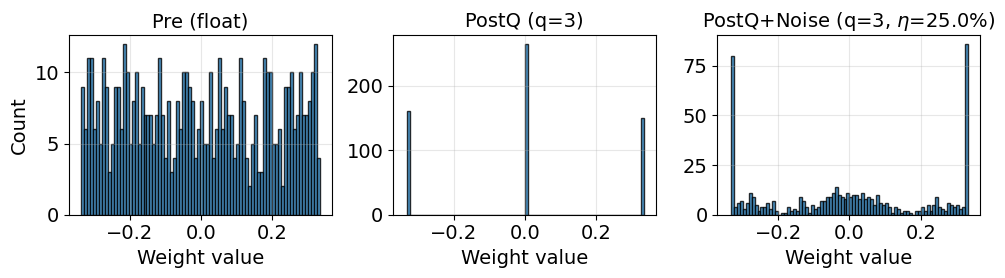

In [9]:
q = 2
x = 4.0
res = plot_weight_histograms_single_layer(
    fold_id=1,
    ds=ds2,
    folds=folds2,
    device=device,
    param_list=PARAM_LIST,
    target_group="Conv1",         # e.g. focus on pooled temporal convs
    batch_size=BATCH_SIZE,
    spike_ts=SPIKE_TS,
    q=q,
    x=x,
    seed=5,
    bins=80,
    save_path=f"../../results/figures/hist_Conv1_fold1_q{q}_x{x}.svg",
)

Loading cached min/max results from ../../results/postprocessing/min_max_per_layer_q2.csv


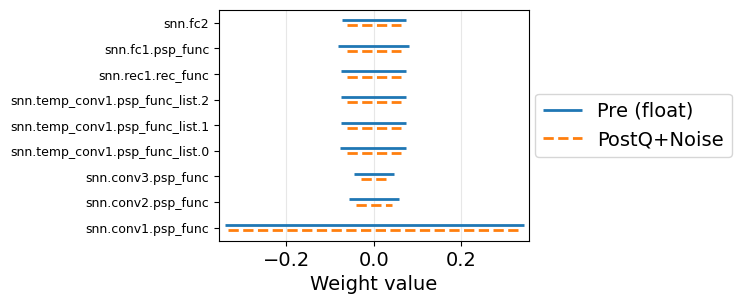

In [10]:
q_plot = 2
csv_path = f"../../results/postprocessing/min_max_per_layer_q{q_plot}.csv"

if os.path.exists(csv_path):
    print(f"Loading cached min/max results from {csv_path}")
    df_mm = pd.read_csv(csv_path)
else:
    print(f"{csv_path} not found, computing min/max per layer...")
    df_mm = compute_min_max_per_layer_over_folds(
        q=q_plot,
        folds=folds2,
        ds=ds2,
        device=device,
        param_list=PARAM_LIST,
        batch_size=BATCH_SIZE,
        spike_ts=SPIKE_TS,
        save=True,
        save_path=csv_path,
    )

# if there are multiple q in the file, filter
df_mm = df_mm[df_mm["q"] == q_plot].copy()

# preserve layer order as in the CSV
layers = df_mm["layer"].tolist()
mins_before = df_mm["min_before"].values
maxs_before = df_mm["max_before"].values
mins_after  = df_mm["min_after"].values
maxs_after  = df_mm["max_after"].values

n = len(layers)
y = np.arange(n)

plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(4, 3))

# before quant: solid line
for i in range(n):
    ax.hlines(y[i] + 0.1, mins_before[i], maxs_before[i],
              linewidth=2, color="C0")  # slight vertical offset
# after quant: dashed line
for i in range(n):
    ax.hlines(y[i] - 0.1, mins_after[i], maxs_after[i],
              linewidth=2, color="C1", linestyles="--")

ax.set_yticks(y)
ax.set_yticklabels(layers, fontsize=9)
ax.set_xlabel("Weight value")
ax.grid(True, axis='x', alpha=0.3)

# global x-limits with padding
gmin = min(min(mins_before), min(mins_after))
gmax = max(max(maxs_before), max(maxs_after))
M = max(abs(gmin), abs(gmax))
pad = 0.03 * M
ax.set_xlim(-(M + pad), M + pad)

# Legend handles
blue_line = ax.hlines([], [], [], color="C0", linewidth=2)
orange_line = ax.hlines([], [], [], color="C1", linewidth=2, linestyles="--")
ax.legend([blue_line, orange_line], ["Pre (float)", "PostQ+Noise"],
          bbox_to_anchor=(1.02, 0.5), loc= "center left", borderaxespad=0.0)

plt.savefig("../../results/figures/min_max_per_layer_q2.svg")
plt.show()

/tmp/ipykernel_912262/1995960599.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(pretrained_model_path, map_location=device))


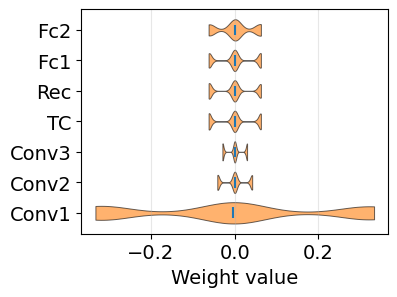

In [11]:
# -----------------------
# Example usage:
# -----------------------
# plot_weight_violins_single_fold(
#     fold_id=1, ds=ds2, folds=folds2, device=device, param_list=PARAM_LIST,
#     batch_size=BATCH_SIZE, spike_ts=SPIKE_TS,
#     mode="pre", save_path="Figures/violin_pre_fold1.svg"
# )
#
# plot_weight_violins_single_fold(
#     fold_id=1, ds=ds2, folds=folds2, device=device, param_list=PARAM_LIST,
#     batch_size=BATCH_SIZE, spike_ts=SPIKE_TS,
#     mode="postq", q=2, save_path="Figures/violin_postq_fold1_q2.svg"
# )
q=2
x=10.0
plot_weight_violins_single_fold(
    fold_id=1, ds=ds2, folds=folds2, device=device, param_list=PARAM_LIST,
    batch_size=BATCH_SIZE, spike_ts=SPIKE_TS,
    mode="postqn", q=q, x=x, seed=5,
    save_path=f"../../results/figures/violin_postqn_fold1_q{q}_x{x}.svg"
)
